bold_candidates: ['C:\\Users\\cierr\\OneDrive\\CompNeuro\\sub-p41cs\\ses-001\\func\\sub-p41cs_ses-001_task-movie_run-1_bold.nii.gz']
json_candidates: ['C:\\Users\\cierr\\OneDrive\\CompNeuro\\sub-p41cs\\ses-001\\func\\sub-p41cs_ses-001_task-movie_run-1_bold.json']
fmri_data shape: (80, 80, 56, 500)
TR: 1.0
n_trs: 500
fmri_time_sec shape: (500,)
mean_img shape: (80, 80, 56)
mask voxels: 99615
Y_fmri shape [T, V]: (500, 99615)


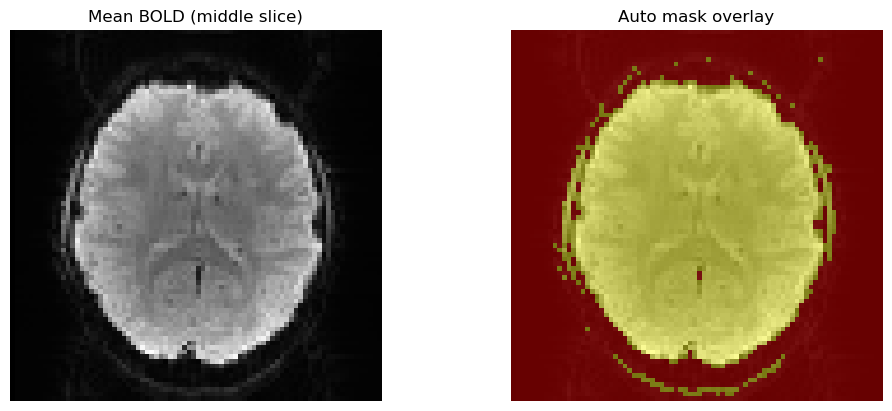

In [15]:
import json
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# --------------------------------------------------
# Exact file paths from your screenshots
# --------------------------------------------------

import os
import glob

func_dir = r"C:\Users\cierr\OneDrive\CompNeuro\sub-p41cs\ses-001\func"

bold_candidates = sorted(glob.glob(os.path.join(func_dir, "*run-1*_bold.nii*")))
json_candidates = sorted(glob.glob(os.path.join(func_dir, "*run-1*_bold.json")))

print("bold_candidates:", bold_candidates)
print("json_candidates:", json_candidates)

bold_path = bold_candidates[0]
json_path = json_candidates[0]


# --------------------------------------------------
# Load BOLD + metadata
# --------------------------------------------------
fmri_img = nib.load(bold_path)
fmri_data = fmri_img.get_fdata()

with open(json_path, "r") as f:
    meta = json.load(f)

TR = float(meta["RepetitionTime"])
n_trs = fmri_data.shape[3]
fmri_time_sec = np.arange(n_trs, dtype=float) * TR

print("fmri_data shape:", fmri_data.shape)
print("TR:", TR)
print("n_trs:", n_trs)
print("fmri_time_sec shape:", fmri_time_sec.shape)

# --------------------------------------------------
# Build a simple brain mask from the mean BOLD image
# --------------------------------------------------
mean_img = np.nanmean(fmri_data, axis=3)

# Simple threshold:
# keep voxels with mean intensity > 20% of the 95th percentile
p95 = np.nanpercentile(mean_img, 95)
thr = 0.20 * p95
mask = np.isfinite(mean_img) & (mean_img > thr)

print("mean_img shape:", mean_img.shape)
print("mask voxels:", int(mask.sum()))

# Wrap mask into a nib image so later code can reuse it
brain_mask_img = nib.Nifti1Image(mask.astype(np.uint8), affine=fmri_img.affine, header=fmri_img.header)

# --------------------------------------------------
# Convert fMRI into [T, V]
# --------------------------------------------------
Y_fmri = fmri_data[mask].T.astype(np.float32)

print("Y_fmri shape [T, V]:", Y_fmri.shape)

# --------------------------------------------------
# Quick QC plot: middle slice mean image + mask
# --------------------------------------------------
z = mean_img.shape[2] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

axes[0].imshow(np.rot90(mean_img[:, :, z]), cmap="gray")
axes[0].set_title("Mean BOLD (middle slice)")
axes[0].axis("off")

axes[1].imshow(np.rot90(mean_img[:, :, z]), cmap="gray")
axes[1].imshow(np.rot90(mask[:, :, z]), cmap="autumn", alpha=0.4)
axes[1].set_title("Auto mask overlay")
axes[1].axis("off")

plt.show()


In [16]:
from pathlib import Path
import pickle
import pandas as pd
from new_code import slicer, label

# --------------------------------------------------
# Load face annotations robustly
# --------------------------------------------------
candidate_paths = [
    Path.cwd() / ".." / ".." / "assets" / "annotations" / "short_faceannots.pkl",
    Path.cwd() / ".." / "assets" / "annotations" / "short_faceannots.pkl",
    Path.cwd() / "assets" / "annotations" / "short_faceannots.pkl",
]

face_annots_path = None
for p in candidate_paths:
    p = p.resolve()
    if p.exists():
        face_annots_path = p
        break

if face_annots_path is None:
    raise FileNotFoundError(
        "Could not find short_faceannots.pkl. Tried:\n" +
        "\n".join(str(p.resolve()) for p in candidate_paths)
    )

with open(face_annots_path, "rb") as f:
    face_annots = pickle.load(f)

df_face_note = label.build_face_feature_df(face_annots, target_id="Jacky")

print("Loaded face annotations from:", face_annots_path)
print("df_face_note shape:", df_face_note.shape)
print(df_face_note.head())

# --------------------------------------------------
# Exact face feature models from your main notebook
# --------------------------------------------------
face_feature_sets = {
    "quantity": ["n_faces", "total_face_area", "max_face_area"],
    "identity": ["Jacky_present"],
    "pose_emotion": [
        "any_front_face",
        "emo_afraid", "emo_angry", "emo_happy",
        "emo_neutral", "emo_surprised"
    ],
    "all_face": [
        "n_faces", "total_face_area", "max_face_area",
        "Jacky_present", "any_front_face",
        "emo_afraid", "emo_angry", "emo_happy",
        "emo_neutral", "emo_surprised"
    ]
}

method_map = {
    "n_faces": "nearest",
    "total_face_area": "linear",
    "max_face_area": "linear",
    "Jacky_present": "nearest",
    "any_front_face": "nearest",
    "emo_afraid": "nearest",
    "emo_angry": "nearest",
    "emo_happy": "nearest",
    "emo_neutral": "nearest",
    "emo_surprised": "nearest",
}

print("face_feature_sets keys:", list(face_feature_sets.keys()))
print("method_map keys:", list(method_map.keys()))


Loaded face annotations from: C:\Users\cierr\OneDrive\Documents\GitHub\CompNeuro_CDT\assets\annotations\short_faceannots.pkl
df_face_note shape: (9378, 14)
   frame_key  frame_idx  movie_time  n_faces  total_face_area  max_face_area  \
0  frame_118        118        4.72        2     13399.852594    8546.745649   
1  frame_119        119        4.76        2     13571.000000    8620.500000   
2  frame_120        120        4.80        2     13289.500000    8411.000000   
3  frame_121        121        4.84        2     13265.500000    8293.000000   
4  frame_122        122        4.88        2     13307.000000    8334.500000   

   Jacky_present  any_front_face dominant_emotion  emo_afraid  emo_angry  \
0              1               0          neutral       False      False   
1              1               0          neutral       False      False   
2              1               0          neutral       False      False   
3              1               0          neutral       Fal

Running fMRI encoding for model: quantity
Running fMRI encoding for model: identity
Running fMRI encoding for model: pose_emotion
Running fMRI encoding for model: all_face


,face_model,mean_corr,median_corr,mean_r2,median_r2,n_voxels
3,all_face,0.128362,0.132451,-67.914701,-26.723161,99615
1,identity,-0.281990,-0.275315,-0.591169,-0.352424,99615
2,pose_emotion,0.124276,0.099366,-61.521593,-20.809606,99615
0,quantity,-0.127791,-0.127364,-0.200385,-0.152874,99615


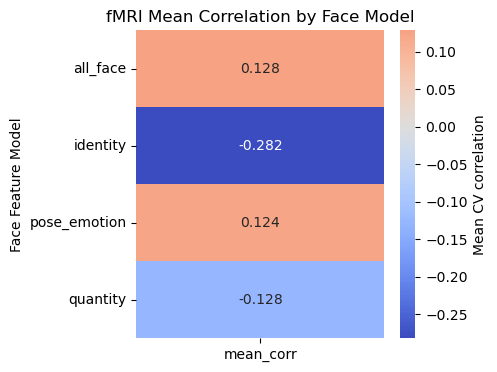

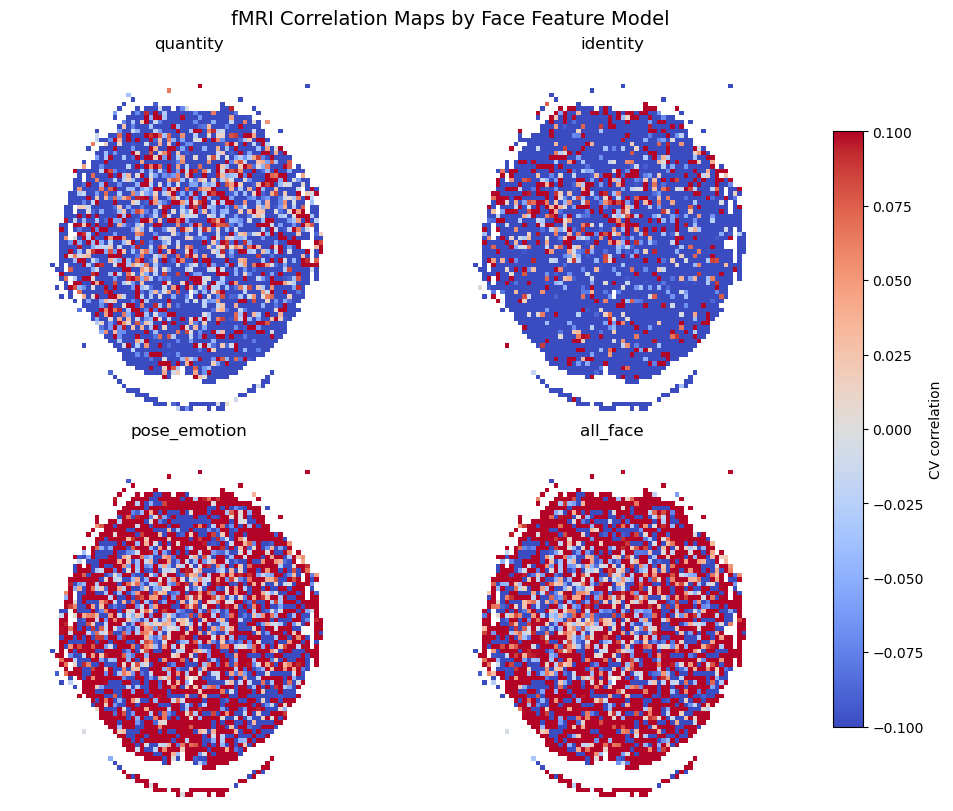

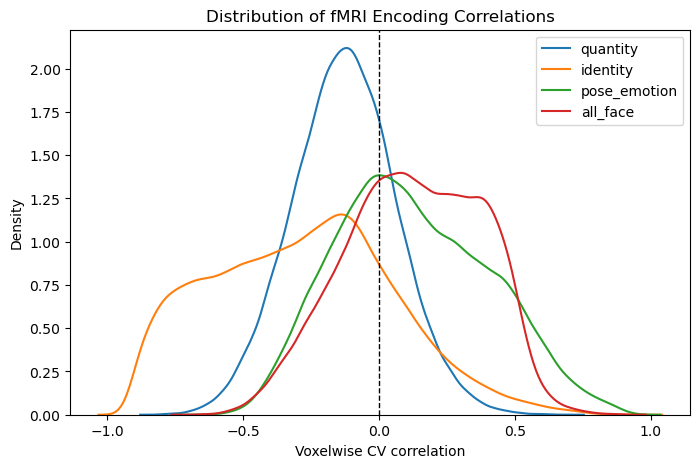

In [21]:
import numpy as np
import math
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# =========================================================
# USER SETTINGS
# =========================================================
alpha = 10.0
n_splits = 5
smooth_sec = 0.30   # smooth discrete face regressors before HRF
vlim = 0.10         # color scale for correlation maps

# =========================================================
# HELPERS
# =========================================================

def spm_like_hrf(tr, oversampling=16, time_length=32.0):
    dt = tr / oversampling
    t = np.arange(0, time_length, dt)

    peak1 = 6
    peak2 = 16
    under_scale = 1 / 6.0

    hrf = (
        (t ** (peak1 - 1) * np.exp(-t))
        / math.gamma(peak1)
        - under_scale * (t ** (peak2 - 1) * np.exp(-t))
        / math.gamma(peak2)
    )

    hrf = np.nan_to_num(hrf, nan=0.0, posinf=0.0, neginf=0.0)
    if np.max(np.abs(hrf)) > 0:
        hrf = hrf / np.max(np.abs(hrf))
    return hrf


def convolve_design_hrf(X, tr):
    X = np.asarray(X, dtype=float)
    hrf = spm_like_hrf(tr)
    Xc = np.zeros_like(X, dtype=float)

    for j in range(X.shape[1]):
        conv = np.convolve(X[:, j], hrf, mode="full")[: X.shape[0]]
        Xc[:, j] = conv

    return Xc


def smooth_face_predictors(df_face_grid, cols_to_smooth, dt, smooth_sec=0.30):
    df_sm = df_face_grid.copy()

    if smooth_sec is None or smooth_sec <= 0:
        return df_sm

    win = max(1, int(round(float(smooth_sec) / float(dt))))
    if win % 2 == 0:
        win += 1

    binary_like = {
        "Jacky_present",
        "any_front_face",
        "emo_afraid",
        "emo_angry",
        "emo_happy",
        "emo_neutral",
        "emo_surprised",
    }

    for col in cols_to_smooth:
        if col not in df_sm.columns:
            continue

        x = pd.Series(df_sm[col].astype(float).to_numpy())
        x_sm = x.rolling(window=win, center=True, min_periods=1).mean().to_numpy()

        if col in binary_like:
            x_sm = np.clip(x_sm, 0.0, 1.0)
        elif col == "n_faces":
            x_sm = np.clip(x_sm, 0.0, None)

        df_sm[col] = x_sm

    return df_sm


def ridge_encoding_cv_multioutput(X, Y, alpha=10.0, n_splits=5):
    """
    X: [T, D]
    Y: [T, V]
    Returns voxelwise CV correlation and R2.
    """
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    valid_rows = np.all(np.isfinite(X), axis=1) & np.all(np.isfinite(Y), axis=1)
    X = X[valid_rows]
    Y = Y[valid_rows]

    T = X.shape[0]
    V = Y.shape[1]

    if T < n_splits:
        return {
            "corr": np.full(V, np.nan),
            "r2": np.full(V, np.nan),
            "pred": np.full((T, V), np.nan),
        }

    fold_edges = np.linspace(0, T, n_splits + 1).astype(int)
    preds = np.full((T, V), np.nan, dtype=float)

    for i in range(n_splits):
        te0, te1 = fold_edges[i], fold_edges[i + 1]
        te_idx = np.arange(te0, te1)
        tr_idx = np.setdiff1d(np.arange(T), te_idx)

        xtr, xte = X[tr_idx], X[te_idx]
        ytr = Y[tr_idx]

        x_scaler = StandardScaler()
        y_scaler = StandardScaler()

        xtr = x_scaler.fit_transform(xtr)
        xte = x_scaler.transform(xte)
        ytr_z = y_scaler.fit_transform(ytr)

        model = Ridge(alpha=alpha)
        model.fit(xtr, ytr_z)

        yhat_z = model.predict(xte)
        yhat = y_scaler.inverse_transform(yhat_z)
        preds[te_idx] = yhat

    corr = np.full(V, np.nan)
    r2 = np.full(V, np.nan)

    for v in range(V):
        pv = preds[:, v]
        yv = Y[:, v]

        good = np.isfinite(pv) & np.isfinite(yv)
        if good.sum() < 3:
            continue

        yy = yv[good]
        pp = pv[good]

        if np.std(yy) > 0 and np.std(pp) > 0:
            corr[v] = np.corrcoef(yy, pp)[0, 1]

        if np.var(yy) > 0:
            r2[v] = 1.0 - np.sum((yy - pp) ** 2) / np.sum((yy - np.mean(yy)) ** 2)

    return {"corr": corr, "r2": r2, "pred": preds}


def vector_to_nifti(values, mask_img, reference_img):
    mask = mask_img.get_fdata().astype(bool)
    out = np.full(mask.shape, np.nan, dtype=np.float32)
    out[mask] = values.astype(np.float32)
    return nib.Nifti1Image(out, affine=reference_img.affine, header=reference_img.header)


def show_middle_slice_on_axis(ax, img, title="", cmap="coolwarm", vmin=-0.1, vmax=0.1):
    data = img.get_fdata()
    z = data.shape[2] // 2
    im = ax.imshow(np.rot90(data[:, :, z]), cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
    return im


# =========================================================
# BUILD FACE DESIGN ON fMRI TIME GRID
# =========================================================

tr = float(np.median(np.diff(fmri_time_sec)))

all_face_cols = sorted({col for cols in face_feature_sets.values() for col in cols})

df_face_grid = slicer.resample_face_df_to_timegrid(
    df_face_note,
    fmri_time_sec,
    all_face_cols,
    method_map=method_map,
)

smooth_cols = [
    "Jacky_present",
    "any_front_face",
    "emo_afraid",
    "emo_angry",
    "emo_happy",
    "emo_neutral",
    "emo_surprised",
]

df_face_grid = smooth_face_predictors(
    df_face_grid=df_face_grid,
    cols_to_smooth=smooth_cols,
    dt=tr,
    smooth_sec=smooth_sec,
)

# =========================================================
# RUN ENCODING FOR EACH FACE MODEL
# =========================================================

fmri_results = {}
fmri_corr_imgs = {}
fmri_r2_imgs = {}

for model_name, cols in face_feature_sets.items():
    print(f"Running fMRI encoding for model: {model_name}")

    X = df_face_grid[cols].astype(float).to_numpy()
    X_hrf = convolve_design_hrf(X, tr=tr)

    res = ridge_encoding_cv_multioutput(
        X=X_hrf,
        Y=Y_fmri,
        alpha=alpha,
        n_splits=n_splits,
    )

    fmri_results[model_name] = res

    fmri_corr_imgs[model_name] = vector_to_nifti(
        values=res["corr"],
        mask_img=brain_mask_img,
        reference_img=fmri_img,
    )

    fmri_r2_imgs[model_name] = vector_to_nifti(
        values=res["r2"],
        mask_img=brain_mask_img,
        reference_img=fmri_img,
    )

# =========================================================
# SUMMARY TABLE
# =========================================================

rows = []
for model_name, res in fmri_results.items():
    rows.append({
        "face_model": model_name,
        "mean_corr": np.nanmean(res["corr"]),
        "median_corr": np.nanmedian(res["corr"]),
        "mean_r2": np.nanmean(res["r2"]),
        "median_r2": np.nanmedian(res["r2"]),
        "n_voxels": int(np.sum(np.isfinite(res["corr"]))),
    })

df_fmri_summary = pd.DataFrame(rows).sort_values("face_model")
display(df_fmri_summary)

# =========================================================
# PLOT 1: Heatmap like your other model summaries
# =========================================================

heat_df = df_fmri_summary.set_index("face_model")[["mean_corr"]]

plt.figure(figsize=(4, 4))
sns.heatmap(
    heat_df,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Mean CV correlation"},
)
plt.title("fMRI Mean Correlation by Face Model")
plt.ylabel("Face Feature Model")
plt.xlabel("")
plt.show()

# =========================================================
# PLOT 2: 2x2 brain-map panel
# =========================================================

model_order = ["quantity", "identity", "pose_emotion", "all_face"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
axes = axes.ravel()

ims = []
for ax, model_name in zip(axes, model_order):
    im = show_middle_slice_on_axis(
        ax,
        fmri_corr_imgs[model_name],
        title=model_name,
        cmap="coolwarm",
        vmin=-vlim,
        vmax=vlim,
    )
    ims.append(im)

cbar = fig.colorbar(ims[0], ax=axes, shrink=0.8)
cbar.set_label("CV correlation")

fig.suptitle("fMRI Correlation Maps by Face Feature Model", fontsize=14)
plt.show()

# =========================================================
# PLOT 3: Distribution of voxelwise correlations
# =========================================================

plt.figure(figsize=(8, 5))
for model_name in model_order:
    corr = np.asarray(fmri_results[model_name]["corr"], dtype=float)
    corr = corr[np.isfinite(corr)]
    if len(corr) > 1:
        sns.kdeplot(corr, label=model_name, fill=False)

plt.axvline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Voxelwise CV correlation")
plt.ylabel("Density")
plt.title("Distribution of fMRI Encoding Correlations")
plt.legend()
plt.show()
